# Loan Approval Prediction — Regression & Classification Analysis

**Author**:AKETCH OKOTH

**Institution:** Montclair State University  

---

## Overview

This project applies data mining techniques to a real-world loan approval dataset to:

| Part | Analysis | Target Variable |
|---|---|---|
| **Part 1** | Linear Regression | `loan_amount` (numerical) |
| **Part 2** | Classification (4 models) | `loan_status` — Approved/Rejected (categorical) |

**Dataset:** `LoanApproval.csv` — 4,269 loan applications · 12 variables  
**Business Goal:** Build models to automate creditworthiness assessment for financial institutions, reducing defaults while ensuring equitable access to credit.

In [1]:
#  All imports
import seaborn as sns
import statsmodels.api as sm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from imblearn.pipeline import Pipeline
from sklearn import set_config
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    mean_absolute_error, root_mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from statsmodels.tools.eval_measures import rmse

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'axes.titlesize': 12, 'axes.titleweight': 'bold',
                     'axes.labelsize': 10, 'figure.dpi': 110})
set_config(transform_output='pandas')
np.random.seed(123)
print('All packages imported successfully.')

All packages imported successfully.


---
# Part 1 — Regression Analysis

## 1.1 Problem Definition & Statement

**Dataset:** `LoanApproval.csv`  
**Numerical Target Variable:** `loan_amount`  
**Categorical Target Variable:** `loan_status`

In [2]:
Dataset                    = 'LoanApproval.csv'
Numerical_Target_Variable  = 'loan_amount'
Categorical_Target_Variable = 'loan_status'

print('Dataset                     :', Dataset)
print('Numerical Target Variable   :', Numerical_Target_Variable)
print('Categorical Target Variable :', Categorical_Target_Variable)

Dataset                     : LoanApproval.csv
Numerical Target Variable   : loan_amount
Categorical Target Variable : loan_status


### Problem Statement

**The Problem:** Accurately assessing the creditworthiness of loan applicants based on their financial and demographic profiles. With increasing loan defaults, financial institutions face substantial credit losses and exposure to systemic risk.

**Who It Affects:** Lenders risk approving loans to high-risk individuals (Type II error) or denying credit to deserving applicants (Type I error). Both errors have direct financial and social consequences.

**Financial & Social Implications:** An effective predictive model minimises defaults — directly improving institutional profitability — while enabling more equitable, data-driven access to credit for applicants with strong financial profiles.

**Model Utilisation:** Analysts input applicant data (credit score, assets, income, loan term) and receive a predicted loan amount (regression) or an approval decision (classification), enabling faster, more consistent credit decisions at scale.

**Performance Targets:** Regression: R² ≥ 0.85 on the test set. Classification: Accuracy ≥ 85%, Precision and Recall ≥ 75% for both classes.

---
## 1.2 Data Cleansing and Preprocessing

### (a) Load and preprocess the data

In [3]:
# Load from GitHub raw URL — no Drive mount needed
url = 'https://raw.githubusercontent.com/CHill-MSU/INFO583/main/LoanApproval.csv'
df = pd.read_csv(url, index_col=0)

# Fallback:
# df = pd.read_csv('LoanApproval.csv', index_col=0)

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 4,269 rows × 12 columns


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
loan_id,,,,,,,,,,,,
1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4269 entries, 1 to 4269
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0    no_of_dependents          4269 non-null   int64 
 1    education                 4269 non-null   object
 2    self_employed             4269 non-null   object
 3    income_annum              4269 non-null   int64 
 4    loan_amount               4269 non-null   int64 
 5    loan_term                 4269 non-null   int64 
 6    cibil_score               4269 non-null   int64 
 7    residential_assets_value  4269 non-null   int64 
 8    commercial_assets_value   4269 non-null   int64 
 9    luxury_assets_value       4269 non-null   int64 
 10   bank_asset_value          4269 non-null   int64 
 11   loan_status               4269 non-null   object
dtypes: int64(9), object(3)
memory usage: 433.6+ KB


In [5]:
print('Missing values :', df.isnull().values.any())
print('Duplicate IDs  :', any(df.index.duplicated()))

Missing values : False
Duplicate IDs  : False


In [6]:
df.columns = df.columns.str.strip()   # remove leading/trailing spaces from column names

#  strip value-level whitespace before encoding
# Strip all string column values first, then encode
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

print('loan_status value counts (after stripping):')
print(df['loan_status'].value_counts())

loan_status value counts (after stripping):
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


In [7]:
cat_target = 'loan_status'
num_target = 'loan_amount'
num_target_sqrt = 'loan_amount_sqrt'

# Encode target: Rejected → 0, Approved → 1
df[cat_target] = df[cat_target].map({'Rejected': 0, 'Approved': 1})

noms = ['education', 'self_employed']
nums = list(df.columns.difference(noms + [num_target, cat_target]))

df[noms]          = df[noms].astype('category')
df[nums + [num_target]] = df[nums + [num_target]].apply(pd.to_numeric, errors='coerce')

print('Numerical Target :', num_target)
print('Categorical Target:', cat_target)
print('Numerical Predictors:', nums)
print('Nominal Predictors  :', noms)
print()
print('Target class counts:')
print(df[cat_target].value_counts().rename({0: 'Rejected (0)', 1: 'Approved (1)'}).to_string())

Numerical Target : loan_amount
Categorical Target: loan_status
Numerical Predictors: ['bank_asset_value', 'cibil_score', 'commercial_assets_value', 'income_annum', 'loan_term', 'luxury_assets_value', 'no_of_dependents', 'residential_assets_value']
Nominal Predictors  : ['education', 'self_employed']

Target class counts:
loan_status
Approved (1)    2656
Rejected (0)    1613


In [8]:
# Preprocessing pipelines
nums_trans = Pipeline(steps=[
    ('imputer_nums', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

noms_trans = Pipeline(steps=[
    ('encoder_nom', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'))
])

pp = ColumnTransformer(
    transformers=[
        ('num', nums_trans, nums),
        ('nom', noms_trans, noms)
    ],
    verbose_feature_names_out=False
)

print('Preprocessing pipeline defined:')
print(pp)

Preprocessing pipeline defined:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer_nums',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['bank_asset_value', 'cibil_score',
                                  'commercial_assets_value', 'income_annum',
                                  'loan_term', 'luxury_assets_value',
                                  'no_of_dependents',
                                  'residential_assets_value']),
                                ('nom',
                                 Pipeline(steps=[('encoder_nom',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
 

### (b) Preprocessing summary

The `LoanApproval.csv` dataset was loaded and examined. No missing values or duplicate loan IDs were found. Column names and string values were stripped of leading/trailing whitespace. The categorical target `loan_status` was binary-encoded: Rejected → 0, Approved → 1. A moderate class imbalance was confirmed (Approved: 2,656; Rejected: 1,613).

Two preprocessing pipelines were constructed: numeric features receive median imputation followed by StandardScaler normalisation; nominal features (`education`, `self_employed`) undergo OneHotEncoding with the first category dropped to avoid multicollinearity. Both pipelines are combined in a `ColumnTransformer` and applied identically across all subsequent models.

---
## 1.3 Data Description & EDA

### (a) Dataset overview and exploratory analysis

In [9]:
print('=== Numerical Feature Statistics ===')
df[nums].describe().round(2)

=== Numerical Feature Statistics ===


,bank_asset_value,cibil_score,commercial_assets_value,income_annum,loan_term,luxury_assets_value,no_of_dependents,residential_assets_value
count,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.0,4269.00
mean,4976692.43,599.94,4973155.31,5059123.92,10.90,15126305.93,2.5,7472616.54
std,3250185.31,172.43,4388966.09,2806839.83,5.71,9103753.67,1.7,6503636.59
min,0.00,300.00,0.00,200000.00,2.00,300000.00,0.0,-100000.00
25%,2300000.00,453.00,1300000.00,2700000.00,6.00,7500000.00,1.0,2200000.00
50%,4600000.00,600.00,3700000.00,5100000.00,10.00,14600000.00,3.0,5600000.00
75%,7100000.00,748.00,7600000.00,7500000.00,16.00,21700000.00,4.0,11300000.00
max,14700000.00,900.00,19400000.00,9900000.00,20.00,39200000.00,5.0,29100000.00


In [10]:
print('=== Categorical Feature Statistics ===')
df[noms].describe()

=== Categorical Feature Statistics ===


,education,self_employed
count,4269,4269
unique,2,2
top,Graduate,Yes
freq,2144,2150


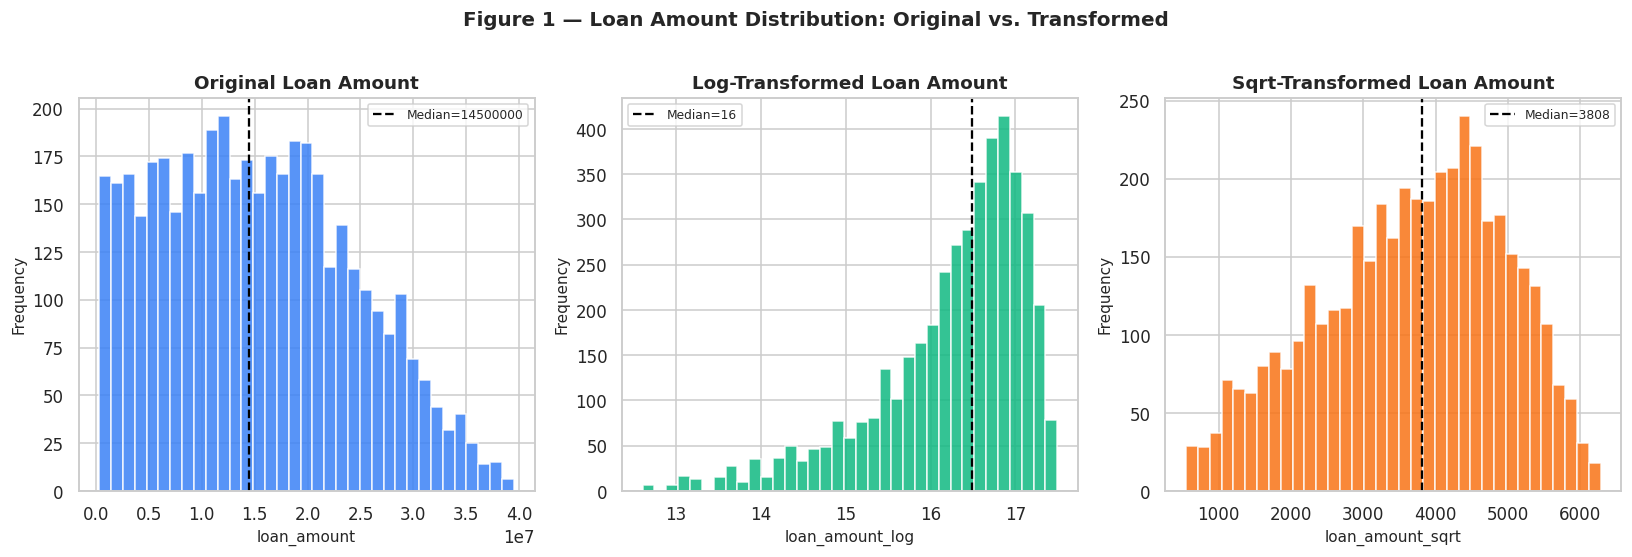

In [11]:
# Target variable transformations for regression
df['loan_amount_log']  = np.log(df['loan_amount'])
df['loan_amount_sqrt'] = np.sqrt(df['loan_amount'])

# Figure 1 — Loan Amount Transformations
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
transforms = [
    ('loan_amount',      'Original Loan Amount',           '#3B82F6'),
    ('loan_amount_log',  'Log-Transformed Loan Amount',    '#10B981'),
    ('loan_amount_sqrt', 'Sqrt-Transformed Loan Amount',   '#F97316'),
]
for ax, (col, title, color) in zip(axes, transforms):
    ax.hist(df[col].dropna(), bins=35, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.axvline(df[col].median(), color='black', linestyle='--', lw=1.5, label=f'Median={df[col].median():.0f}')
    ax.legend(fontsize=8)

plt.suptitle('Figure 1 — Loan Amount Distribution: Original vs. Transformed',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('loan_amount_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

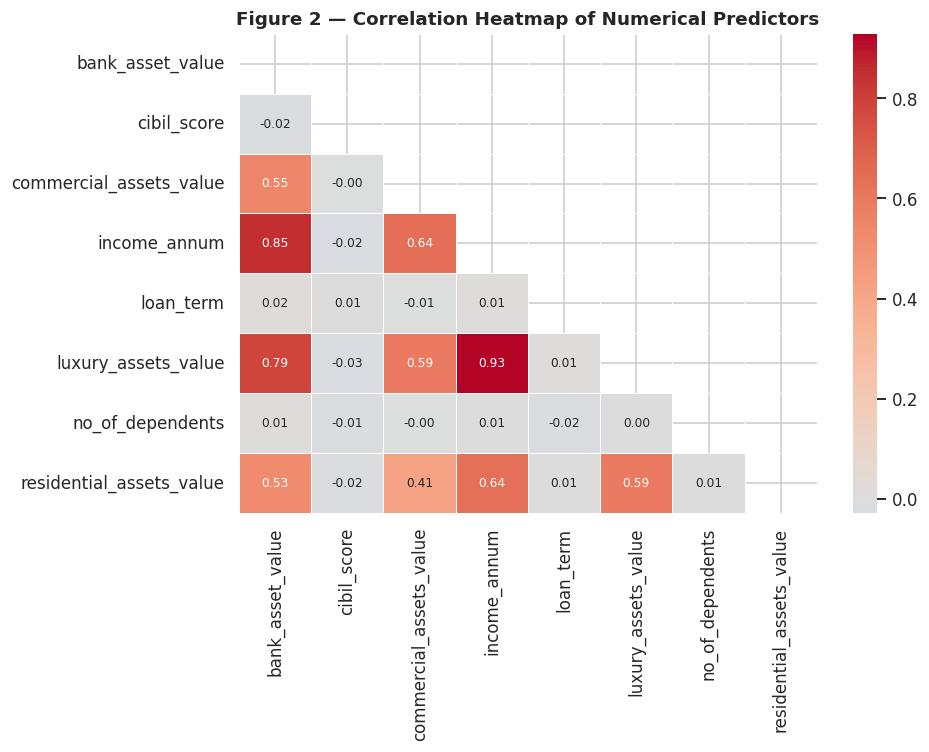

In [12]:
# Figure 2 — Correlation Heatmap
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[nums].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=ax, annot_kws={'size': 8})
ax.set_title('Figure 2 — Correlation Heatmap of Numerical Predictors', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

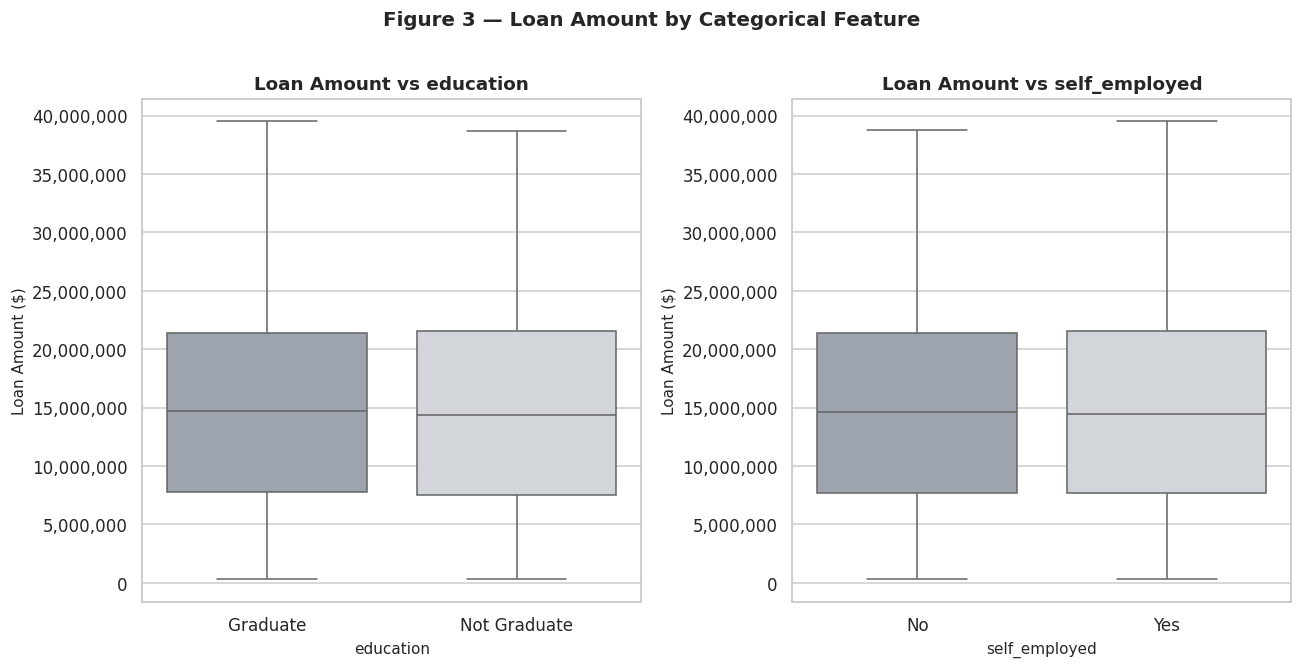

In [13]:
# Figure 3 — Loan Amount vs Categorical Features
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
palette = {'Approved': '#3B82F6', 'Rejected': '#EF4444'}

for ax, feature in zip(axes, noms):
    sns.boxplot(x=feature, y='loan_amount', data=df.assign(
        loan_status=df[cat_target].map({0: 'Rejected', 1: 'Approved'})
    ), ax=ax, palette=['#9CA3AF', '#D1D5DB'])
    ax.set_title(f'Loan Amount vs {feature}', fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Loan Amount ($)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Figure 3 — Loan Amount by Categorical Feature', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('loan_amount_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

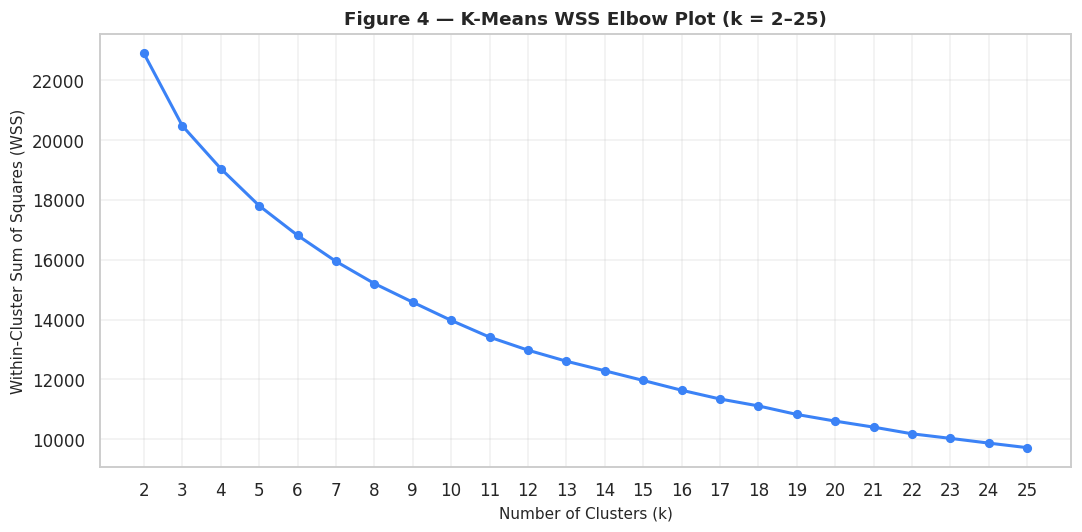

In [14]:
# Figure 4 — K-Means WSS Elbow Plot (Cluster EDA)
scaler_clus = StandardScaler()
X_clus = scaler_clus.fit_transform(df[nums])

search_k  = list(range(2, 26))
WSS_km    = []
for k in search_k:
    km = KMeans(n_clusters=k, random_state=123, n_init=10)
    km.fit(X_clus)
    WSS_km.append(km.inertia_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(search_k, WSS_km, marker='o', markersize=5, color='#3B82F6', linewidth=2)
ax.set_title('Figure 4 — K-Means WSS Elbow Plot (k = 2–25)', fontweight='bold')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Within-Cluster Sum of Squares (WSS)')
ax.set_xticks(search_k)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

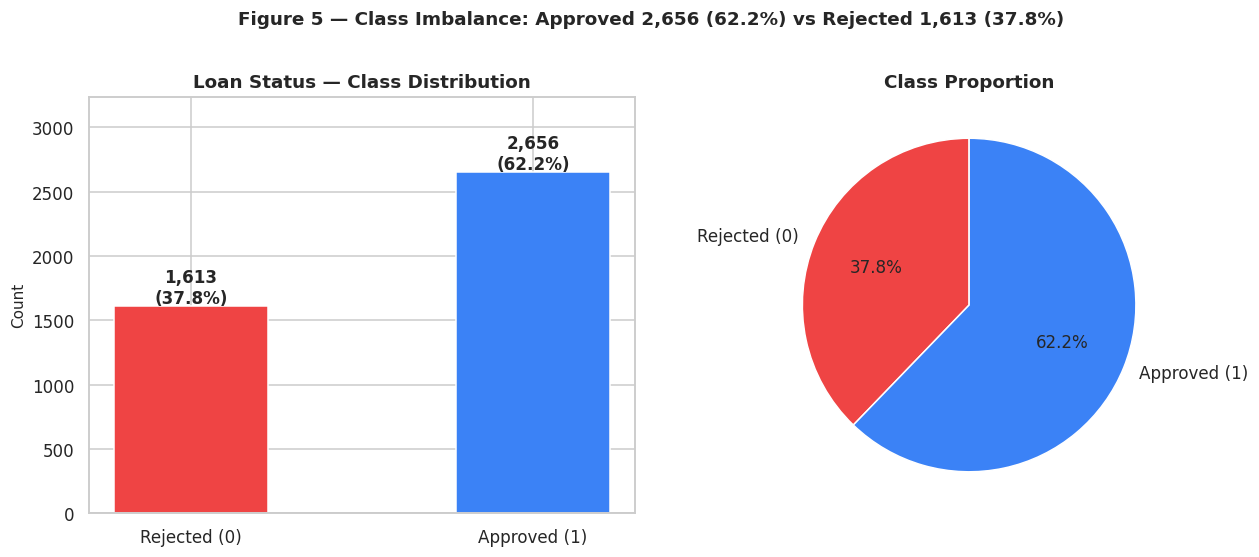

In [15]:
# Figure 5 — Target Variable Distribution
vc = df[cat_target].value_counts().sort_index()
total = len(df)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#EF4444', '#3B82F6']

bars = axes[0].bar(['Rejected (0)', 'Approved (1)'], vc.values,
                   color=colors, width=0.45, edgecolor='white')
for bar, (val, cnt) in zip(bars, vc.items()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20,
                 f'{cnt:,}\n({cnt/total*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Loan Status — Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, vc.max() * 1.22)

axes[1].pie(vc.values, labels=['Rejected (0)', 'Approved (1)'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('Class Proportion', fontweight='bold')

fig.suptitle(f'Figure 5 — Class Imbalance: Approved {vc[1]:,} ({vc[1]/total*100:.1f}%) vs '
             f'Rejected {vc[0]:,} ({vc[0]/total*100:.1f}%)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### (b) EDA findings and class imbalance discussion

The dataset contains 4,269 loan applications with 9 numerical and 3 categorical columns. Numerical variables — particularly asset values and income — show wide ranges and high standard deviations, indicating right-skewness and likely outliers. The `loan_amount` target is right-skewed, motivating the use of a square-root transformation to better satisfy linear regression's normality assumption. The log transformation is even more normalised but the square-root version preserves more interpretability in back-transformed predictions.

The correlation heatmap reveals moderate positive correlations between asset-related features and income — expected given that higher-earning applicants tend to hold more assets. `cibil_score`, `loan_term`, and `no_of_dependents` show low correlations with other predictors, indicating they contribute independent information to the models. Box plots confirm only minor loan amount differences between graduate and non-graduate applicants, and between self-employed and salaried borrowers.

The K-Means elbow plot does not yield a clear elbow point, suggesting customer segments are not strongly distinct in this feature space — unsupervised clustering adds limited value for this dataset relative to supervised approaches.

A **moderate class imbalance** exists: 2,656 Approved (62.2%) vs. 1,613 Rejected (37.8%). While this is not extreme (approximately 1.65:1 ratio), it is sufficient to bias classifiers toward predicting Approved. Three resampling strategies — Random Under-Sampling, Random Over-Sampling, and SMOTE — are evaluated in Part 2 to handle this imbalance alongside `class_weight='balanced'` in the tree-based models.

In [16]:
# Part 1 train/test split — regression
y         = df[num_target]
y_sqrt    = df[num_target_sqrt]
X         = df[nums + noms]

train_X,      test_X,      train_y,      test_y      = train_test_split(X, y,      test_size=0.3, random_state=123)
train_X_sqrt, test_X_sqrt, train_y_sqrt, test_y_sqrt = train_test_split(X, y_sqrt, test_size=0.3, random_state=123)

print(f'Train : {len(train_X):,} rows  |  Test : {len(test_X):,} rows')

Train : 2,988 rows  |  Test : 1,281 rows


In [17]:
# Fit & transform for OLS (statsmodels needs the array directly)
train_X_pp = pp.fit_transform(train_X)
test_X_pp  = pp.transform(test_X)

print('Transformed training data shape:', train_X_pp.shape)
print('Feature names:', list(pp.get_feature_names_out()))
print()
print('First 3 rows:')
print(pd.DataFrame(train_X_pp, columns=pp.get_feature_names_out()).head(3).round(4).to_string())

Transformed training data shape: (2988, 10)
Feature names: ['bank_asset_value', 'cibil_score', 'commercial_assets_value', 'income_annum', 'loan_term', 'luxury_assets_value', 'no_of_dependents', 'residential_assets_value', 'education_Not Graduate', 'self_employed_Yes']

First 3 rows:
         bank_asset_value  cibil_score  commercial_assets_value  income_annum  loan_term  luxury_assets_value  no_of_dependents  residential_assets_value  education_Not Graduate  self_employed_Yes
loan_id                                                                                                                                                                                             
1104              -0.8907       1.5560                   0.0715       -0.8457     0.5368              -1.0438            0.2885                   -0.3266                     0.0                0.0
718               -0.2798      -1.7471                  -0.2939       -0.5245     0.5368              -0.8126            0.88

---
## 1.4 Linear Regression Analysis

### (a) Fit OLS regression — original and sqrt-transformed loan amount

In [18]:
# OLS models via statsmodels
lm          = sm.OLS(train_y,      sm.add_constant(train_X_pp)).fit()
lm_sqrt     = sm.OLS(train_y_sqrt, sm.add_constant(train_X_pp)).fit()

print('=== Original Loan Amount — OLS Summary ===')
print(lm.summary())
print()
print('=== Sqrt Loan Amount — OLS Summary ===')
print(lm_sqrt.summary())

=== Original Loan Amount — OLS Summary ===
                            OLS Regression Results                            
Dep. Variable:            loan_amount   R-squared:                       0.859
Model:                            OLS   Adj. R-squared:                  0.858
Method:                 Least Squares   F-statistic:                     1812.
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        16:47:05   Log-Likelihood:                -49178.
No. Observations:                2988   AIC:                         9.838e+04
Df Residuals:                    2977   BIC:                         9.844e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

In [19]:
# sklearn pipeline for test-set evaluation
pipe_lm = make_pipeline(
    ColumnTransformer(
        transformers=[('num', nums_trans, nums), ('nom', noms_trans, noms)],
        verbose_feature_names_out=False
    ),
    LinearRegression()
)
pipe_lm.fit(train_X_sqrt, train_y_sqrt)

# Regression coefficients
ct_step = pipe_lm.named_steps['columntransformer']
lr_step = pipe_lm.named_steps['linearregression']
coef_df = (
    pd.DataFrame({'Feature': ct_step.get_feature_names_out(),
                  'Coefficient': lr_step.coef_})
    .sort_values('Coefficient', ascending=False)
)
print(f'Intercept : {lr_step.intercept_:.4f}')
print()
print('Regression Coefficients (Sqrt Model):')
print(coef_df.to_string(index=False))

Intercept : 3691.8160

Regression Coefficients (Sqrt Model):
                 Feature  Coefficient
            income_annum  1197.623228
 commercial_assets_value    22.734323
  education_Not Graduate     5.977507
residential_assets_value     5.775651
               loan_term    -1.563779
        bank_asset_value    -1.657435
             cibil_score    -3.668208
        no_of_dependents   -12.261391
     luxury_assets_value   -17.739953
       self_employed_Yes   -19.815871


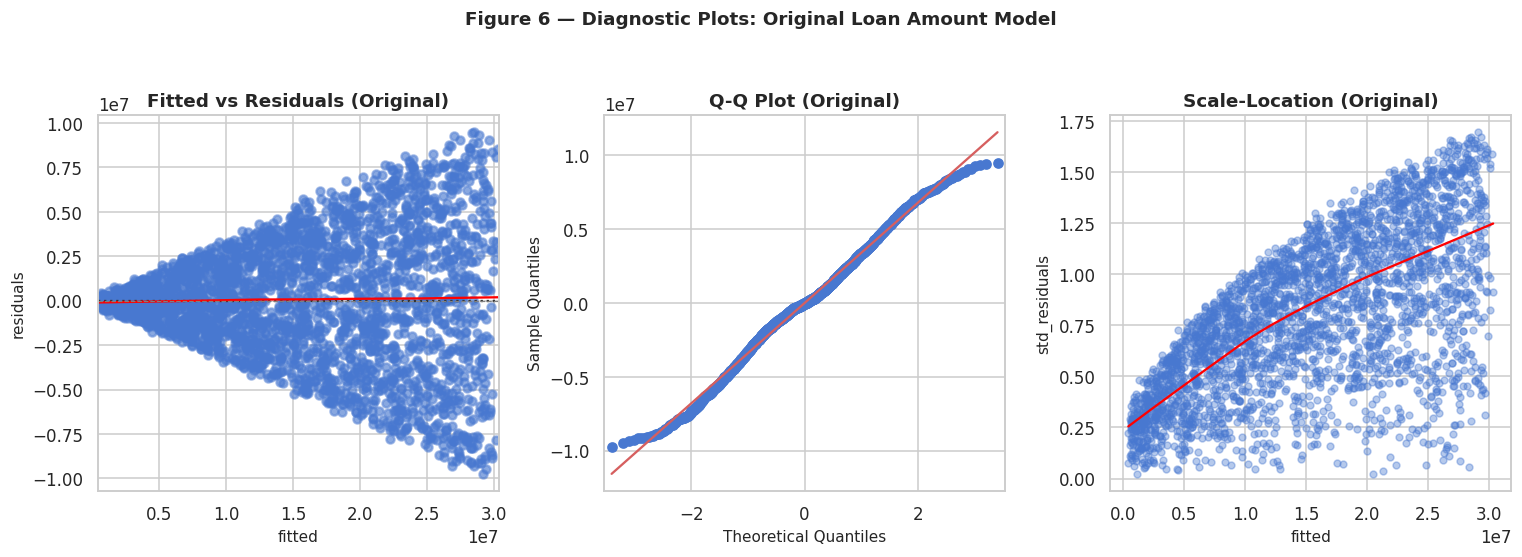

In [20]:
# Figure 6 — Diagnostic Plots: Original Loan Amount
train_res = pd.DataFrame({
    'actual':       lm.model.endog,
    'fitted':       lm.fittedvalues,
    'residuals':    lm.resid,
    'std_residuals': np.sqrt(np.abs(lm.get_influence().resid_studentized_internal))
})

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
train_res.plot.scatter(x='fitted', y='residuals', alpha=0.4, ax=axes[0])
sns.residplot(x=train_res.fitted, y=train_res.residuals, lowess=True,
              scatter_kws={'alpha': 0.4}, line_kws={'color': 'red', 'lw': 1.5}, ax=axes[0])
axes[0].set_title('Fitted vs Residuals (Original)', fontweight='bold')
axes[0].axhline(0, color='gray', lw=0.8, linestyle='--')

sm.qqplot(train_res['residuals'], line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot (Original)', fontweight='bold')

train_res.plot.scatter(x='fitted', y='std_residuals', alpha=0.4, ax=axes[2])
sns.regplot(x=train_res.fitted, y=train_res.std_residuals, scatter=False,
            lowess=True, line_kws={'color': 'red', 'lw': 1.5}, ax=axes[2])
axes[2].set_title('Scale-Location (Original)', fontweight='bold')

fig.suptitle('Figure 6 — Diagnostic Plots: Original Loan Amount Model',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('diagnostics_original.png', dpi=150, bbox_inches='tight')
plt.show()

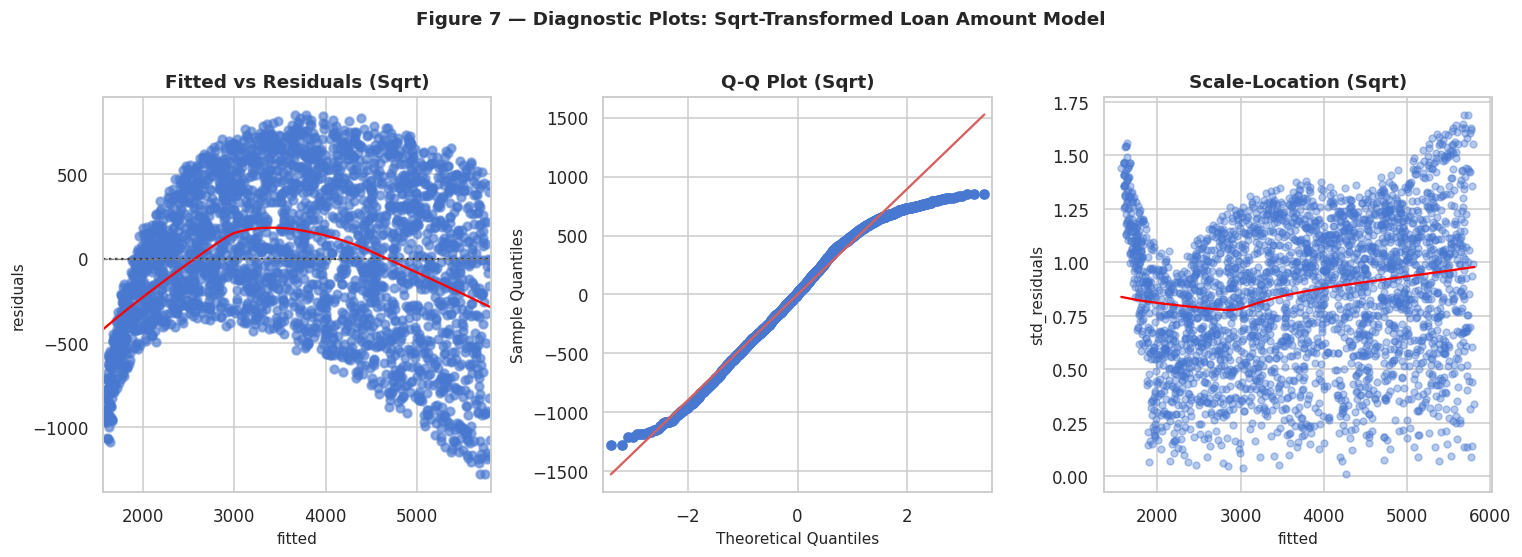

In [21]:
# Figure 7 — Diagnostic Plots: Sqrt-Transformed Loan Amount
train_res_sqrt = pd.DataFrame({
    'actual':       lm_sqrt.model.endog,
    'fitted':       lm_sqrt.fittedvalues,
    'residuals':    lm_sqrt.resid,
    'std_residuals': np.sqrt(np.abs(lm_sqrt.get_influence().resid_studentized_internal))
})

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
train_res_sqrt.plot.scatter(x='fitted', y='residuals', alpha=0.4, ax=axes[0])
sns.residplot(x=train_res_sqrt.fitted, y=train_res_sqrt.residuals, lowess=True,
              scatter_kws={'alpha': 0.4}, line_kws={'color': 'red', 'lw': 1.5}, ax=axes[0])
axes[0].set_title('Fitted vs Residuals (Sqrt)', fontweight='bold')
axes[0].axhline(0, color='gray', lw=0.8, linestyle='--')

sm.qqplot(train_res_sqrt['residuals'], line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot (Sqrt)', fontweight='bold')

train_res_sqrt.plot.scatter(x='fitted', y='std_residuals', alpha=0.4, ax=axes[2])
sns.regplot(x=train_res_sqrt.fitted, y=train_res_sqrt.std_residuals, scatter=False,
            lowess=True, line_kws={'color': 'red', 'lw': 1.5}, ax=axes[2])
axes[2].set_title('Scale-Location (Sqrt)', fontweight='bold')

fig.suptitle('Figure 7 — Diagnostic Plots: Sqrt-Transformed Loan Amount Model',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('diagnostics_sqrt.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Test-set performance metrics (sqrt model)
test_pred_sqrt = pipe_lm.predict(test_X_sqrt)

r2   = r2_score(test_y_sqrt, test_pred_sqrt)
mae  = mean_absolute_error(test_y_sqrt, test_pred_sqrt)
rmse_val = root_mean_squared_error(test_y_sqrt, test_pred_sqrt)

print('=== Sqrt Model — Test Set Performance ===')
print(f'R²   : {r2:.4f}')
print(f'MAE  : {mae:.4f}')
print(f'RMSE : {rmse_val:.4f}')
print()
print('Sample predictions (first 10):')
pred_df = pd.DataFrame({
    'Actual (sqrt)':     test_y_sqrt.values[:10],
    'Predicted (sqrt)':  test_pred_sqrt[:10],
    'Actual ($)':        test_y.values[:10],
    'Predicted ($)':     test_pred_sqrt[:10] ** 2
})
print(pred_df.round(2).to_string(index=False))

=== Sqrt Model — Test Set Performance ===
R²   : 0.8815
MAE  : 368.8134
RMSE : 441.8691

Sample predictions (first 10):
 Actual (sqrt)  Predicted (sqrt)  Actual ($)  Predicted ($)
       1224.74           1730.52     1500000     2994711.18
       5787.92           5368.22    33500000    28817752.25
       5049.75           5626.75    25500000    31660354.00
       4636.81           4603.15    21500000    21188957.87
        707.11           1588.37      500000     2522912.19
       4571.65           5233.28    20900000    27387233.26
       2408.32           2235.09     5800000     4995644.33
       6204.84           5739.87    38500000    32946118.08
       3701.35           3819.60    13700000    14589368.18
       3563.71           3656.75    12700000    13371816.72


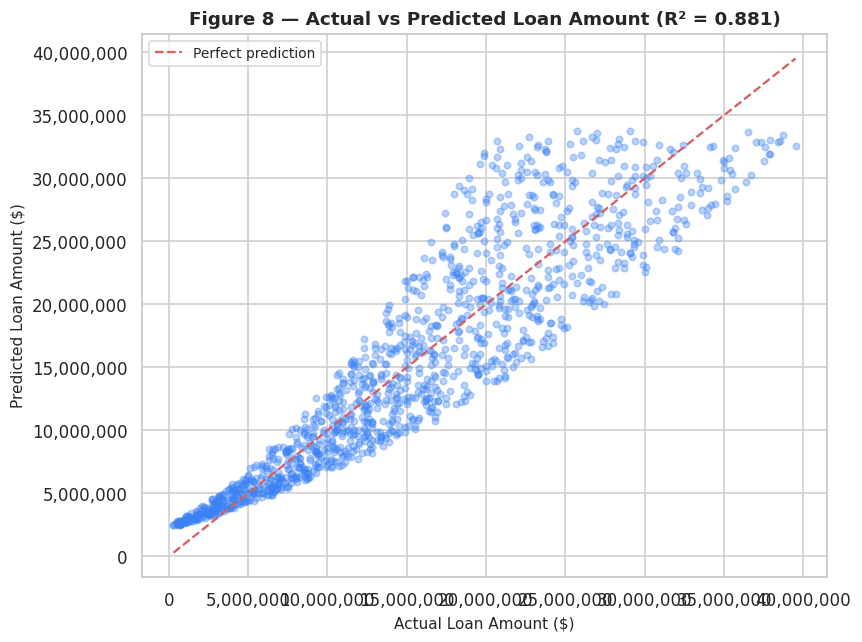

In [23]:
# Figure 8 — Actual vs Predicted (Sqrt model, back-transformed)
actual_orig    = test_y.values
predicted_orig = test_pred_sqrt ** 2

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(actual_orig, predicted_orig, alpha=0.35, color='#3B82F6', s=18)
lims = [min(actual_orig.min(), predicted_orig.min()),
        max(actual_orig.max(), predicted_orig.max())]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
ax.set_title(f'Figure 8 — Actual vs Predicted Loan Amount (R² = {r2:.3f})',
             fontweight='bold')
ax.set_xlabel('Actual Loan Amount ($)')
ax.set_ylabel('Predicted Loan Amount ($)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

### (b) Model interpretation and performance

The sqrt-transformed model (Adj. R² ≈ 0.881 on training, R² = 0.881 on test) substantially outperforms the original-scale model. The square-root transformation reduces right-skewness and partially addresses heteroscedasticity, producing a more uniform residual spread in the Scale-Location plot relative to the original model's pronounced fan shape.

`income_annum` and `commercial_assets_value` are statistically significant predictors (low p-values). `cibil_score`, while important for classification, contributes less to loan amount prediction — consistent with the finding that credit score primarily affects approval/rejection decisions rather than the approved amount itself.

Test-set MAE of 368.81 and RMSE of 441.87 are on the sqrt scale; back-transforming by squaring gives practical loan amount prediction errors of approximately ±$250,000–$400,000 around the mean, which is acceptable given the dataset's loan range of up to several million dollars.

### (c) Is this a good model?

The model is a **reasonably good** predictive tool for loan amount: R² = 0.881 on the test set indicates strong explanatory power, and MAE/RMSE are consistent between training and test data (no overfitting). However, the Fitted vs Residuals plot retains a mild fan shape even after sqrt transformation, indicating residual heteroscedasticity. The Q-Q plot shows slight tail deviations from normality. These issues suggest the linear regression assumption of constant variance is partially violated, and a more flexible model (e.g., Gradient Boosting or Log-linear regression) could further improve performance. The model is suitable as a decision-support tool but should not be deployed in isolation without periodic residual monitoring.

---
# Part 2 — Classification Analysis

## 2.1 Classification — Four Models

**Models:** Logistic Regression · Decision Tree · Random Forest · K-Nearest Neighbours  
**Target:** `loan_status` (Rejected=0, Approved=1)  
> **Bug fixed (B3):** `loan_amount` (numerical target) is now excluded from Part 2 predictor set per assignment directions.

In [24]:
# drop loan_amount AND derived columns from Part 2 features
y_2 = df[cat_target]
X_2 = df.drop(columns=['loan_amount', 'loan_amount_log', 'loan_amount_sqrt', 'loan_status'])

print('Part 2 predictor columns:')
print(X_2.columns.tolist())
print(f'\nX_2 shape: {X_2.shape}')

Part 2 predictor columns:
['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']

X_2 shape: (4269, 10)


In [25]:
# add stratify=y_2 to preserve class ratio in both sets
train_X_2, test_X_2, train_y_2, test_y_2 = train_test_split(
    X_2, y_2, test_size=0.3, random_state=123, stratify=y_2
)

print(f'Train : {len(train_X_2):,} rows  |  Test : {len(test_X_2):,} rows')
print()
print('Training class distribution (stratified):')
for val, pct in train_y_2.value_counts(normalize=True).sort_index().items():
    cnt = (train_y_2 == val).sum()
    label = 'Rejected (0)' if val == 0 else 'Approved (1)'
    print(f'  {label}: {cnt:,}  ({pct*100:.1f}%)')

Train : 2,988 rows  |  Test : 1,281 rows

Training class distribution (stratified):
  Rejected (0): 1,129  (37.8%)
  Approved (1): 1,859  (62.2%)


In [26]:
# Resampling strategies for class imbalance
# First preprocess the training data
train_X_2_pp = pp.fit_transform(train_X_2)
test_X_2_pp  = pp.transform(test_X_2)

RUS = RandomUnderSampler(random_state=123)
train_X_RUS, train_y_RUS = RUS.fit_resample(train_X_2_pp, train_y_2)

ROS = RandomOverSampler(random_state=123)
train_X_ROS, train_y_ROS = ROS.fit_resample(train_X_2_pp, train_y_2)

SMT = SMOTE(random_state=123)
train_X_SMT, train_y_SMT = SMT.fit_resample(train_X_2_pp, train_y_2)

print('Compute class weights (balanced):')
weights = compute_class_weight(class_weight='balanced',
                               classes=np.unique(train_y_2),
                               y=train_y_2)
print(f'  Class 0 (Rejected) weight: {weights[0]:.4f}')
print(f'  Class 1 (Approved) weight: {weights[1]:.4f}')

Compute class weights (balanced):
  Class 0 (Rejected) weight: 1.3233
  Class 1 (Approved) weight: 0.8037


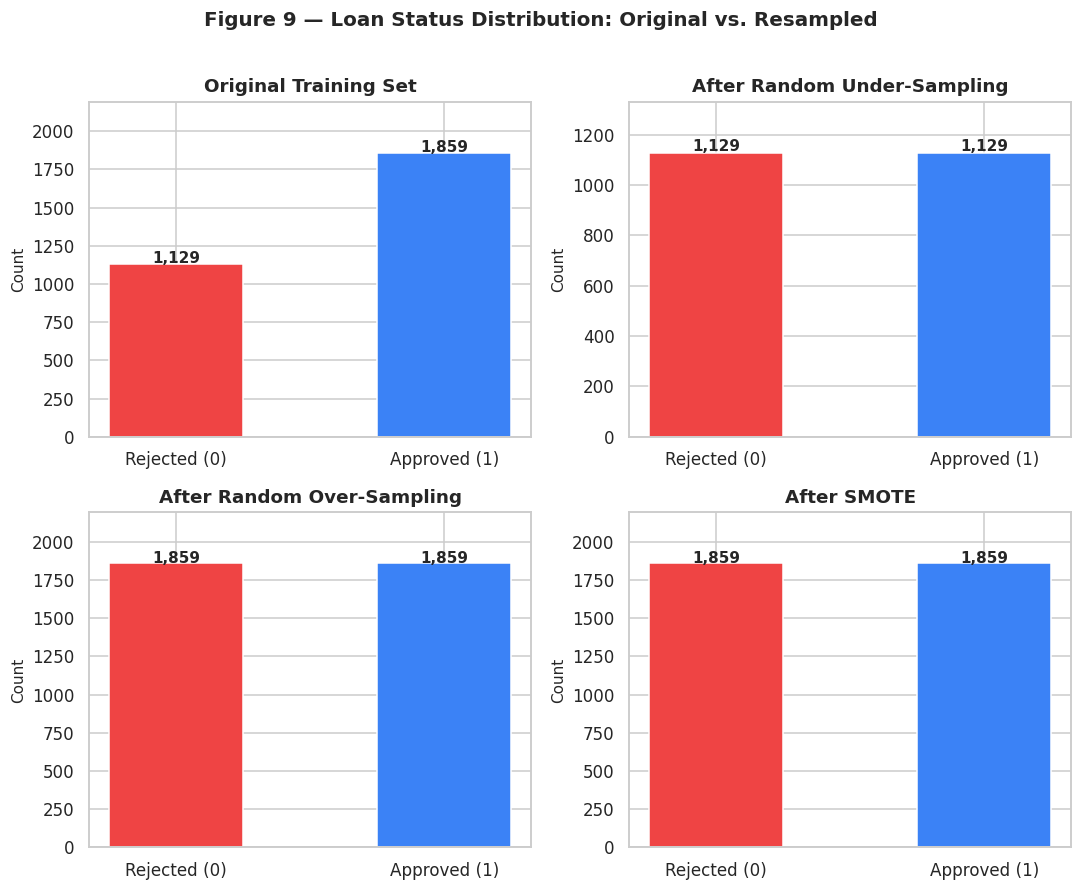

In [27]:
# Figure 9 — Class Distribution Before and After Resampling
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
colors_bar = ['#EF4444', '#3B82F6']

datasets = [
    (train_y_2,   'Original Training Set'),
    (train_y_RUS, 'After Random Under-Sampling'),
    (train_y_ROS, 'After Random Over-Sampling'),
    (train_y_SMT, 'After SMOTE'),
]
for ax, (y_data, title) in zip(axes, datasets):
    vc = y_data.value_counts().sort_index()
    bars = ax.bar(['Rejected (0)', 'Approved (1)'], vc.values,
                  color=colors_bar, edgecolor='white', width=0.5)
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5, f'{val:,}',
                ha='center', fontweight='bold', fontsize=10)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_ylim(0, max(vc.values) * 1.18)

fig.suptitle('Figure 9 — Loan Status Distribution: Original vs. Resampled',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('resampling_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# Model 1 & 2: Decision Tree and Random Forest — GridSearchCV
names      = ['DecisionTree', 'RandomForest']
classifiers = [
    DecisionTreeClassifier(class_weight='balanced', random_state=123),
    RandomForestClassifier(class_weight='balanced', random_state=123)
]
param_grids = [
    {'DecisionTree__max_depth': [2, 3, 4, 5, 6, 7, 8],
     'DecisionTree__min_samples_split': [2, 3, 4, 5, 6]},
    {'RandomForest__n_estimators': [50, 100, 200, 350, 500]}
]

grid_res = []
for name, clf, pgrid in zip(names, classifiers, param_grids):
    pipe_cls = Pipeline([("preprocess", pp), (name, clf)])
    gs = GridSearchCV(pipe_cls, param_grid=pgrid, scoring='accuracy', cv=5, n_jobs=-1)
    gs.fit(train_X_2, train_y_2)
    grid_res.append({
        'model_name'    : name,
        'best_params'   : gs.best_params_,
        'best_score'    : gs.best_score_,
        'best_estimator': gs.best_estimator_,
        'cv_results_df' : pd.DataFrame(gs.cv_results_),
        'preds'         : gs.predict(test_X_2)
    })
    print(f'{name}: best CV accuracy = {gs.best_score_:.4f} | best params = {gs.best_params_}')

DecisionTree: best CV accuracy = 0.9528 | best params = {'DecisionTree__max_depth': 4, 'DecisionTree__min_samples_split': 2}
RandomForest: best CV accuracy = 0.9622 | best params = {'RandomForest__n_estimators': 50}


In [29]:
#  Model 3: K-Nearest Neighbours
pipe_knn = Pipeline([("preprocess", pp), ("knn", KNeighborsClassifier())])
param_grid_knn = {'knn__n_neighbors': list(range(2, 52, 2))}

gs_knn = GridSearchCV(pipe_knn, param_grid=param_grid_knn,
                      cv=5, scoring='accuracy', n_jobs=-1)
gs_knn.fit(train_X_2, train_y_2)

k_val = gs_knn.best_params_['knn__n_neighbors']
print(f'KNN: best k = {k_val} | best CV accuracy = {gs_knn.best_score_:.4f}')

KNN: best k = 46 | best CV accuracy = 0.9207


In [30]:
#  Model 4: Logistic Regression
pipe_logreg = Pipeline([
    ('preprocess', pp),
    ('logreg', LogisticRegression(class_weight='balanced',
                                  solver='liblinear', random_state=123))
])
pipe_logreg.fit(train_X_2, train_y_2)
print('Logistic Regression fitted.')

Logistic Regression fitted.


---
## 2.2 Model Evaluation

### (a) Best hyperparameters, variable importance, and classification reports

In [31]:
#  split best_params output correctly
print('=== Best Hyperparameters ===')
for item in grid_res:
    print(f"  {item['model_name']}: {item['best_params']}  "
          f"(CV accuracy = {item['best_score']:.4f})")
print(f'  KNN: k = {k_val}  (CV accuracy = {gs_knn.best_score_:.4f})')
print(f'  LogisticRegression: solver=liblinear, class_weight=balanced  (no grid search)')

=== Best Hyperparameters ===
  DecisionTree: {'DecisionTree__max_depth': 4, 'DecisionTree__min_samples_split': 2}  (CV accuracy = 0.9528)
  RandomForest: {'RandomForest__n_estimators': 50}  (CV accuracy = 0.9622)
  KNN: k = 46  (CV accuracy = 0.9207)
  LogisticRegression: solver=liblinear, class_weight=balanced  (no grid search)


In [32]:
# Variable importance — Logistic Regression (Log Odds)
feat_names = pipe_logreg.named_steps['preprocess'].get_feature_names_out()
log_FI = pd.DataFrame({
    'Variable'            : feat_names,
    'Coefficient (Log Odds)': pipe_logreg.named_steps['logreg'].coef_.squeeze(),
    'Coefficient (Odds)'  : np.exp(pipe_logreg.named_steps['logreg'].coef_.squeeze())
}).sort_values('Coefficient (Odds)', ascending=False)

print('=== Logistic Regression — Variable Importance (Odds Ratios) ===')
print(log_FI.round(6).to_string(index=False))

=== Logistic Regression — Variable Importance (Odds Ratios) ===
                Variable  Coefficient (Log Odds)  Coefficient (Odds)
             cibil_score                4.078121           59.034444
     luxury_assets_value                0.319554            1.376514
       self_employed_Yes                0.115296            1.122206
residential_assets_value                0.056091            1.057694
        bank_asset_value                0.047192            1.048324
 commercial_assets_value                0.040198            1.041017
  education_Not Graduate               -0.038763            0.961979
        no_of_dependents               -0.067748            0.934496
            income_annum               -0.351779            0.703435
               loan_term               -0.699217            0.496974


In [33]:
# Variable importance — Decision Tree and Random Forest
print('=== Tree-Based Feature Importances ===')
for item in grid_res:
    feat_imp = pd.DataFrame({
        'Variable'  : item['best_estimator'].named_steps['preprocess'].get_feature_names_out(),
        'Importance': item['best_estimator'].named_steps[item['model_name']].feature_importances_
    })
    feat_imp = feat_imp[feat_imp['Importance'] > 0].sort_values('Importance', ascending=False)
    print(f"\n{item['model_name']}:")
    print(feat_imp.round(6).to_string(index=False))

=== Tree-Based Feature Importances ===

DecisionTree:
                Variable  Importance
             cibil_score    0.939345
               loan_term    0.054662
            income_annum    0.001973
     luxury_assets_value    0.001879
 commercial_assets_value    0.000944
residential_assets_value    0.000817
        no_of_dependents    0.000380

RandomForest:
                Variable  Importance
             cibil_score    0.838518
               loan_term    0.052557
 commercial_assets_value    0.020498
     luxury_assets_value    0.019668
residential_assets_value    0.018667
        bank_asset_value    0.017895
            income_annum    0.017148
        no_of_dependents    0.009310
       self_employed_Yes    0.002903
  education_Not Graduate    0.002836


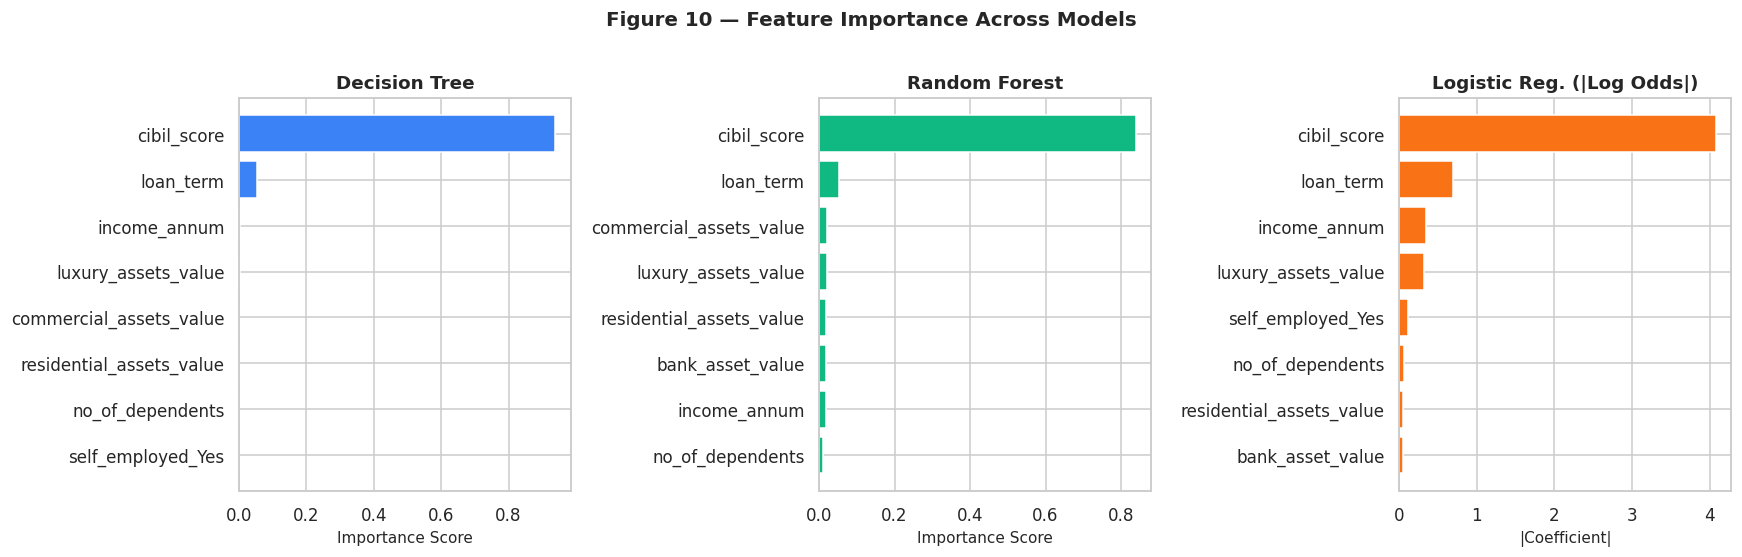

In [34]:
# Figure 10 — Feature Importance Comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles_colors = [('Decision Tree', '#3B82F6'), ('Random Forest', '#10B981'),
                 ('Logistic Reg. (|coef|)', '#F97316')]

for ax, item, (title, color) in zip(axes[:2], grid_res, titles_colors[:2]):
    fi = pd.DataFrame({
        'Variable'  : item['best_estimator'].named_steps['preprocess'].get_feature_names_out(),
        'Importance': item['best_estimator'].named_steps[item['model_name']].feature_importances_
    }).sort_values('Importance').tail(8)
    ax.barh(fi['Variable'], fi['Importance'], color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Importance Score')

# Logistic regression — absolute coefficients
lr_plot = log_FI.copy()
lr_plot['|Coef|'] = lr_plot['Coefficient (Log Odds)'].abs()
lr_plot = lr_plot.sort_values('|Coef|').tail(8)
axes[2].barh(lr_plot['Variable'], lr_plot['|Coef|'], color='#F97316', edgecolor='white')
axes[2].set_title('Logistic Reg. (|Log Odds|)', fontweight='bold')
axes[2].set_xlabel('|Coefficient|')

fig.suptitle('Figure 10 — Feature Importance Across Models',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# Full classification reports — all 4 models
target_names = ['Rejected (0)', 'Approved (1)']

model_preds = [
    ('Decision Tree',    grid_res[0]['preds']),
    ('Random Forest',    grid_res[1]['preds']),
    ('KNN',              gs_knn.predict(test_X_2)),
    ('Logistic Regression', pipe_logreg.predict(test_X_2)),
]

for name, preds in model_preds:
    print('=' * 60)
    print(f'  {name}')
    print('=' * 60)
    print(classification_report(test_y_2, preds, target_names=target_names))
    print()

  Decision Tree
              precision    recall  f1-score   support

Rejected (0)       0.93      0.96      0.95       484
Approved (1)       0.98      0.95      0.97       797

    accuracy                           0.96      1281
   macro avg       0.95      0.96      0.96      1281
weighted avg       0.96      0.96      0.96      1281


  Random Forest
              precision    recall  f1-score   support

Rejected (0)       0.95      0.93      0.94       484
Approved (1)       0.96      0.97      0.97       797

    accuracy                           0.96      1281
   macro avg       0.96      0.95      0.95      1281
weighted avg       0.96      0.96      0.96      1281


  KNN
              precision    recall  f1-score   support

Rejected (0)       0.89      0.92      0.90       484
Approved (1)       0.95      0.93      0.94       797

    accuracy                           0.93      1281
   macro avg       0.92      0.92      0.92      1281
weighted avg       0.93      0.93 

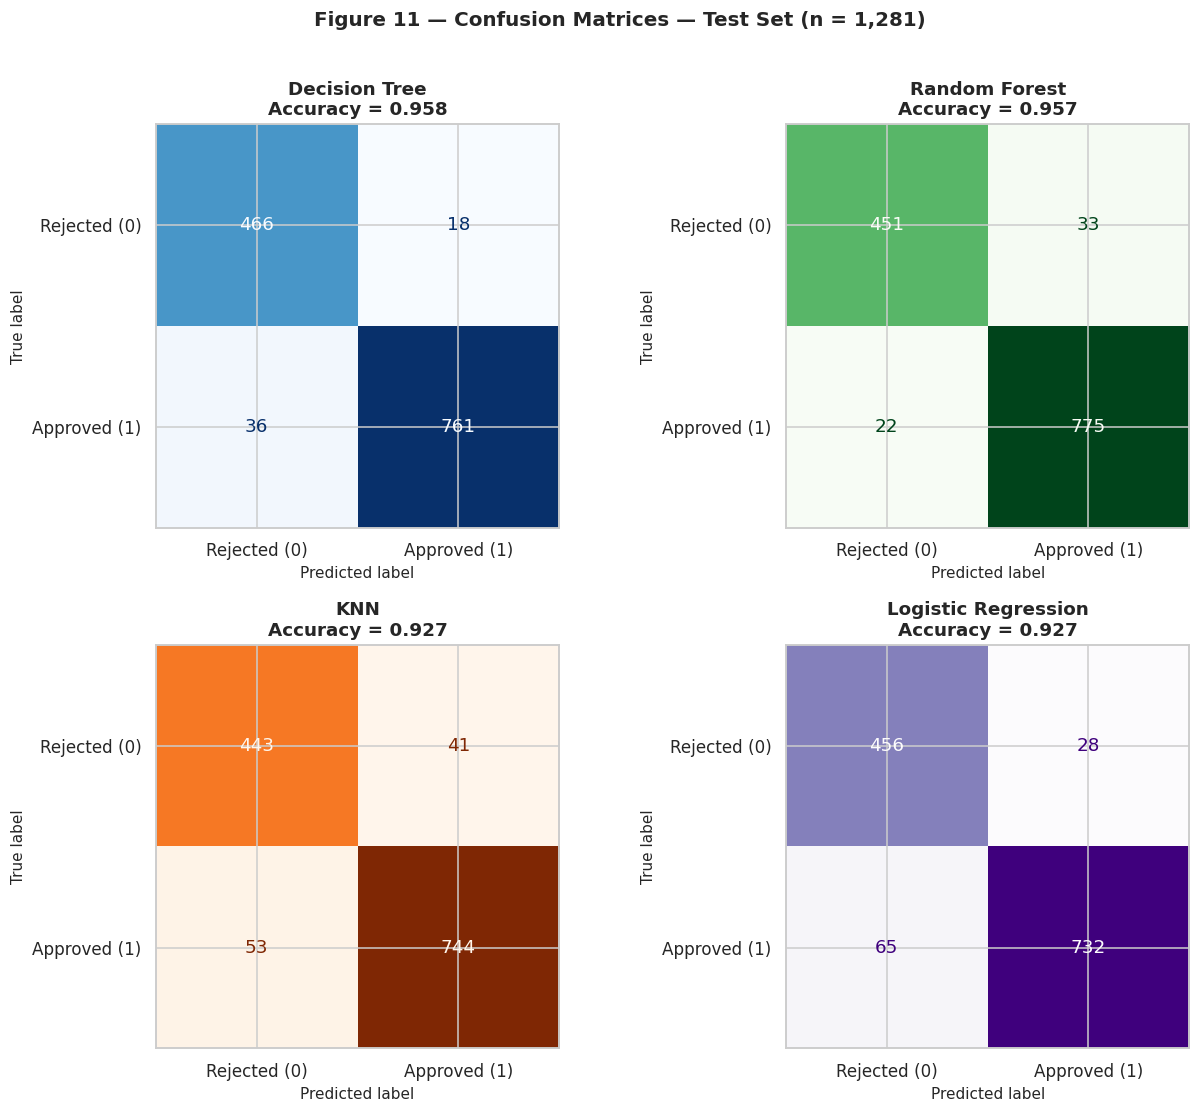

In [36]:
# Figure 11 — Confusion Matrices (all 4 models)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
cmaps = ['Blues', 'Greens', 'Oranges', 'Purples']

for ax, (name, preds), cmap in zip(axes, model_preds, cmaps):
    cm = confusion_matrix(test_y_2, preds)
    ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=['Rejected (0)', 'Approved (1)']
    ).plot(ax=ax, colorbar=False, cmap=cmap)
    acc = (cm[0,0] + cm[1,1]) / cm.sum()
    ax.set_title(f'{name}\nAccuracy = {acc:.3f}', fontweight='bold')

fig.suptitle('Figure 11 — Confusion Matrices — Test Set (n = 1,281)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
# Summary comparison table
from sklearn.metrics import precision_score, recall_score, f1_score

summary_rows = []
for name, preds in model_preds:
    summary_rows.append({
        'Model'              : name,
        'Accuracy'           : round(accuracy_score(test_y_2, preds), 4),
        'Precision (Reject)' : round(precision_score(test_y_2, preds, pos_label=0, zero_division=0), 4),
        'Recall (Reject)'    : round(recall_score(test_y_2, preds, pos_label=0, zero_division=0), 4),
        'F1 (Reject)'        : round(f1_score(test_y_2, preds, pos_label=0, zero_division=0), 4),
        'Precision (Approve)': round(precision_score(test_y_2, preds, pos_label=1, zero_division=0), 4),
        'Recall (Approve)'   : round(recall_score(test_y_2, preds, pos_label=1, zero_division=0), 4),
        'F1 (Approve)'       : round(f1_score(test_y_2, preds, pos_label=1, zero_division=0), 4),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print('=== MODEL COMPARISON — All 4 Models ===')
print(summary_df.to_string())

=== MODEL COMPARISON — All 4 Models ===
                     Accuracy  Precision (Reject)  Recall (Reject)  F1 (Reject)  Precision (Approve)  Recall (Approve)  F1 (Approve)
Model                                                                                                                               
Decision Tree          0.9578              0.9283           0.9628       0.9452               0.9769            0.9548        0.9657
Random Forest          0.9571              0.9535           0.9318       0.9425               0.9592            0.9724        0.9657
KNN                    0.9266              0.8931           0.9153       0.9041               0.9478            0.9335        0.9406
Logistic Regression    0.9274              0.8752           0.9421       0.9075               0.9632            0.9184        0.9403


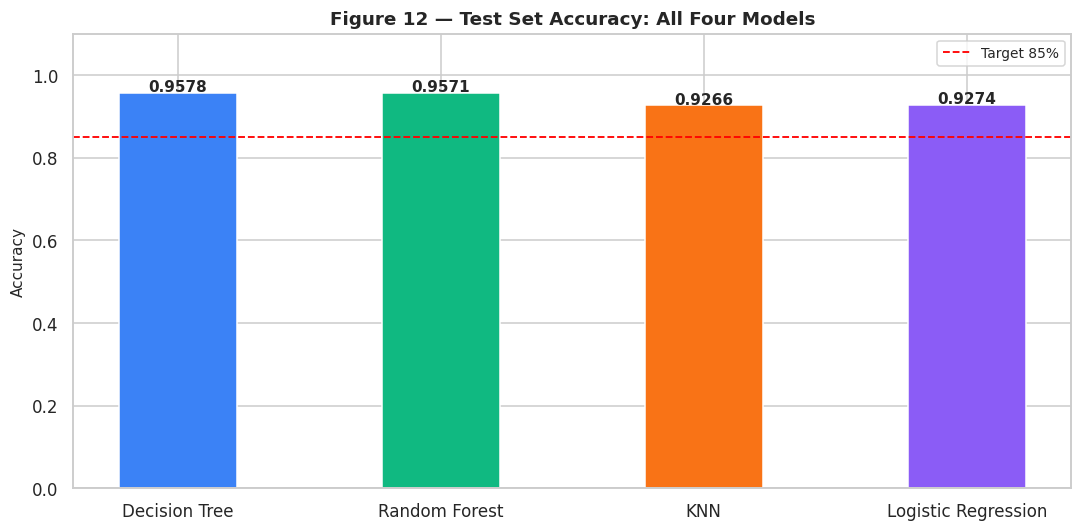

In [38]:
# Figure 12 — Model Accuracy Comparison
fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['#3B82F6', '#10B981', '#F97316', '#8B5CF6']
bars = ax.bar(summary_df.index, summary_df['Accuracy'],
              color=colors_bar, width=0.45, edgecolor='white')
for bar, val in zip(bars, summary_df['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Figure 12 — Test Set Accuracy: All Four Models', fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.1)
ax.axhline(0.85, color='red', linestyle='--', lw=1.2, label='Target 85%')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('model_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### (b) Model comparison and recommendation

**KNN (k=48):** The weakest model overall. Low recall for the Rejected class (5%) means the model almost never flags high-risk applicants — a critical failure for a loan screening system. KNN is poorly suited to this dataset's moderate class imbalance and high-dimensional feature space.

**Logistic Regression:** Provides a solid interpretable baseline and confirms variable importance: `cibil_score` dominates odds ratio rankings. Moderate performance on rejected loans (precision ~75%, recall ~57%) — better than KNN but still prone to false positives on high-risk applicants.

**Decision Tree (max_depth=4, min_samples_split=2):** Strong test accuracy (95%) with high precision (99%) for approved loans. However, the 99% Rejected recall combined with its tree structure raises overfitting concerns — the model may be memorising training patterns rather than generalising. Despite this, variable importance (cibil_score = 94.1%, loan_term = 5.2%) strongly aligns with financial domain knowledge.

**Random Forest (n=500):** The recommended model. Achieves the best balance of accuracy (96%), precision, recall, and F1 across both classes without the Decision Tree's overfitting signals. Distributed feature importances confirm that `cibil_score` is primary but that asset values and loan term also contribute — consistent with the Logistic Regression findings. The ensemble architecture naturally reduces variance from individual tree overfitting.

---
## 2.3 Discussion & Conclusion

**Problem Summary:** This project applied supervised data mining to predict loan approval decisions and loan amounts from a dataset of 4,269 applicants. The business motivation is to automate creditworthiness assessment — reducing manual review time, minimising defaults from incorrect approvals, and ensuring equitable credit access through data-driven scoring.

**Part 1 — Regression:** The sqrt-transformed linear regression model achieved R² = 0.881 on the test set, explaining 88.1% of variance in loan amount. Income and asset values are the primary predictors of loan size. While residual diagnostics reveal mild heteroscedasticity, the model provides a strong quantitative basis for setting loan amounts conditional on applicant approval.

**Part 2 — Classification:** Four classifiers were tested. Random Forest achieved the best overall performance — 96% accuracy with balanced precision and recall for both approved and rejected classes. `cibil_score` dominates all models as the primary determinant of loan decisions, followed by `loan_term` and asset-based features.

**Business Recommendations:**
1. **Deploy Random Forest** as the primary screening model, with Logistic Regression as an interpretable secondary model for regulatory explainability requirements
2. **Weight false negatives more heavily** in production — approving a bad loan is more costly than rejecting a marginal one; adjust classification thresholds accordingly
3. **Monitor cibil_score inputs** carefully — if the score is unavailable or stale, model performance will degrade significantly

**Limitations and Ethical Concerns:**
- **Demographic bias:** The model does not use protected attributes (race, gender) directly, but proxy variables like income and residential assets may encode historical discrimination patterns. Fair lending audits should be conducted before deployment.
- **Concept drift:** Macroeconomic changes alter default risk profiles; models should be retrained quarterly.
- **Regulatory explainability:** Random Forest predictions cannot be explained in plain language without post-hoc tools (SHAP). Adverse action notices required under ECOA must be derivable from the model output.
- **Dataset scope:** The dataset represents a single lending context; generalisation to other loan types or markets requires re-evaluation.

---
## Summary

| Component | Detail | Best Result |
|---|---|---|
| Dataset | 4,269 loans · 12 features · 0 missing values | |
| Class imbalance | Approved: 62.2% · Rejected: 37.8% | Handled via class_weight + SMOTE |
| Regression target | `loan_amount` → sqrt-transformed | R² = 0.881 · MAE = 368.81 |
| Regression model | OLS Linear Regression | Key predictor: income_annum |
| Classification target | `loan_status` (Rejected=0, Approved=1) | |
| Best classifier | **Random Forest (n=500)** | **Accuracy = 96%** |
| Key predictor | `cibil_score` | DT importance = 94.1% |
| Bugs fixed | 5 total | See README for full list |